# 🔍 Exploration OpenAgenda — Phase EDA

**Projet** : Puls-Events RAG POC  
**Objectif** : explorer l'API OpenAgenda, mesurer les données disponibles, décider du périmètre exact.

---

## Plan

1. **Sanity check** — la clé API fonctionne ?
2. **Découverte des agendas parisiens** — quel `uid` choisir ?
3. **Structure d'un événement** — quels champs, quels formats ?
4. **Mesures clés** — volume, longueur, fraîcheur, complétude
5. **Décision finale** — paramètres du POC verrouillés

---

## Pré-requis

- `.env` rempli avec `OPENAGENDA_PUBLIC_KEY`
- packages installés via `requirements.txt`

## 0. Setup

In [42]:
import os
import json
from datetime import datetime, timedelta, timezone
from pathlib import Path

import requests
import pandas as pd

from dotenv import load_dotenv

# Charger les variables d'environnement depuis ../.env
load_dotenv(dotenv_path=Path("..") / ".env")

API_KEY = os.getenv("OPENAGENDA_API_KEY")
BASE_URL = "https://api.openagenda.com/v2"

assert API_KEY, "⚠️ OPENAGENDA_API_KEY manquante dans .env"
print(f"✅ Clé API chargée ({API_KEY[:6]}...)")

✅ Clé API chargée (oa_pk_...)


## 1. Sanity check — la clé fonctionne ?

On appelle la route `/agendas` avec une limite de 1 pour vérifier que l'auth marche.

In [43]:
r = requests.get(
    f"{BASE_URL}/agendas",
    params={"key": API_KEY, "size": 1},
    timeout=10,
)
print(f"Status: {r.status_code}")
if r.ok:
    print("✅ Clé valide")
    print(json.dumps(r.json(), indent=2, ensure_ascii=False)[:500])
else:
    print("❌ Erreur")
    print(r.text[:500])

Status: 200
✅ Clé valide
{
  "after": [
    1,
    54621
  ],
  "agendas": [
    {
      "uid": 54621,
      "image": "https://cdn.openagenda.com/main/agenda54621.6e52bd54eaef4f2e8ef978bd72962685.jpg?__ts=1774609752191",
      "description": "La 43e édition des Journées européennes du patrimoine se déroulera les 19 et 20 septembre 2026. La journée dédiée au public scolaire se déroulera le vendredi 18 septembre (opération « Levez les yeux ! »).",
      "official": true,
      "title": "Journées européennes du patrimoine 


## 2. Découverte des agendas parisiens

Plusieurs agendas couvrent Paris : Mairie de Paris, musées, festivals, etc.  
On va chercher les agendas dont le titre contient "Paris" pour identifier les candidats les plus pertinents.

In [44]:
r = requests.get(
    f"{BASE_URL}/agendas",
    params={
        "key": API_KEY,
        "search": "Paris",
        "size": 20,
    },
    timeout=15,
)
data = r.json()
agendas = data.get("agendas", [])
print(f"📋 {len(agendas)} agendas trouvés contenant 'Paris'\n")

df_agendas = pd.DataFrame([
    {
        "uid": a.get("uid"),
        "title": a.get("title"),
        "slug": a.get("slug"),
        "eventsCount": a.get("eventsCount", 0),
        "locationsCount": a.get("locationsCount", 0),
    }
    for a in agendas
])
df_agendas.sort_values("eventsCount", ascending=False).head(20)

📋 20 agendas trouvés contenant 'Paris'



,uid,title,slug,eventsCount,locationsCount
0,82290100,Diocèse de Paris,dioceseparis,0,0
1,86184123,Université Paris-Saclay,universite-paris-saclay,0,0
18,96240415,Jeunes à Paris,jeunes-a-paris,0,0
17,3541840,Maison de l'Europe de Paris - Europe Direct Paris,europe-direct-paris,0,0
16,15835535,PEC - Paris,pec-paris,0,0
15,2773364,COLLOQUIUM PARIS SA,colloquium-paris-sa,0,0
14,78367046,"Faculté Jean Monnet (Droit, Économie, Manageme...",faculte-droit-economie-management,0,0
13,95630492,CAUE de Paris,caue75,0,0
12,78993009,Paris&Co,parisandco,0,0
11,76783418,Notre-Dame de Paris,notre-dame-de-paris,0,0


**🎯 Action** : observer le top 5 par `eventsCount`. On va probablement choisir l'agenda officiel Mairie de Paris ou le plus volumineux pertinent.

> **Note pour le rapport** : on documente ici la justification du choix d'agenda.

In [45]:
# ⚠️ À AJUSTER après inspection du tableau ci-dessus
# Remplir avec l'uid de l'agenda choisi
AGENDA_UID = 82290100  # ex: 12345678

assert AGENDA_UID is not None, "Choisis l'uid d'un agenda dans le tableau ci-dessus"
print(f"🎯 Agenda cible : {AGENDA_UID}")

🎯 Agenda cible : 82290100


## 3. Structure d'un événement

On récupère 1 événement détaillé pour comprendre la structure JSON.

In [46]:
r = requests.get(
    f"{BASE_URL}/agendas/{AGENDA_UID}/events",
    params={
        "key": API_KEY,
        "size": 1,
        "detailed": 1,
    },
    timeout=15,
)
events = r.json().get("events", [])
print(f"Status: {r.status_code} | events retournés: {len(events)}")

if events:
    sample = events[0]
    print("\n📋 Champs disponibles :")
    for k in sorted(sample.keys()):
        v = sample[k]
        preview = str(v)[:80].replace("\n", " ")
        print(f"  • {k:25s} → {type(v).__name__:10s} | {preview}")

Status: 200 | events retournés: 1

📋 Champs disponibles :
  • accessibility             → dict       | {'ii': False, 'hi': False, 'vi': False, 'pi': False, 'mi': False}
  • addMethod                 → str        | aggregation
  • age                       → dict       | {'min': None, 'max': None}
  • attendanceMode            → int        | 1
  • categories                → list       | []
  • conditions                → dict       | {}
  • country                   → dict       | {'br': 'Frañs (Metropol)', 'de': 'Frankreich (Metropolitan)', 'code': 'FR', 'oc'
  • createdAt                 → str        | 2026-04-19T15:45:33.000Z
  • creatorUid                → int        | 40739516
  • dateRange                 → dict       | {'ar': '٤ مايو - ٤ يوليو', 'de': '4 Mai - 4 Juli', 'en': '4 May - 4 July', 'it':
  • description               → dict       | {'fr': 'Groupe de prière SJBS'}
  • draft                     → int        | 0
  • evenements-lies-au-calendrier → list       | []
  • ext

In [47]:
# Inspection approfondie : description, dates, localisation
if events:
    s = events[0]
    print("=== TITLE ===")
    print(s.get("title"))
    print("\n=== DESCRIPTION (longText) ===")
    print(json.dumps(s.get("longDescription"), indent=2, ensure_ascii=False)[:1000])
    print("\n=== DATERANGE ===")
    print(json.dumps(s.get("dateRange"), indent=2, ensure_ascii=False)[:300])
    print("\n=== LOCATION ===")
    print(json.dumps(s.get("location"), indent=2, ensure_ascii=False)[:500])
    print("\n=== KEYWORDS ===")
    print(s.get("keywords"))

=== TITLE ===
{'fr': 'Prière du Chapelet'}

=== DESCRIPTION (longText) ===
{
  "fr": "Du lundi au samedi à 13h00 à la chapelle Sainte-Geneviève (hors vacances scolaires).\n\nLes paroissiens sont particulièrement invités à prier avec le groupe du chapelet :\n\n– Le chapelet, le 1er samedi de chaque mois,\n\n– Le rosaire, les jours des fêtes mariales suivantes à 13h00 :\n\nLundi 8 septembre 2025 (Nativité de la Vierge Marie)  \nMardi 7 octobre 2025 (Notre Dame du Rosaire)  \nVendredi 21 novembre 2025 (Présentation de Marie)  \nLundi 8 décembre 2025 (Immaculée Conception)  \nMercredi 11 février 2026 (Notre Dame de Lourdes)  \nMercredi 25 mars 2026 (Annonciation)  \nSamedi 13 juin 2026 (Cœur Immaculé de Marie)"
}

=== DATERANGE ===
{
  "ar": "٤ مايو - ٤ يوليو",
  "de": "4 Mai - 4 Juli",
  "en": "4 May - 4 July",
  "it": "4 maggio - 4 luglio",
  "fr": "4 mai - 4 juillet",
  "es": "4 mayo - 4 julio",
  "nl": "4 mei - 4 juli"
}

=== LOCATION ===
{
  "disqualifiedDuplicates": null,
  "access":

**🔍 Observations à noter pour le rapport** :
- Quels champs textuels sont les plus riches pour l'embedding ?
- Y a-t-il du HTML dans `longDescription` ?
- La structure des dates (`dateRange`, `lastTiming`, `nextTiming`) — laquelle utiliser pour le filtre fraîcheur ?
- Champs souvent vides ?

## 4. Mesures clés sur un échantillon plus large

On récupère ~200 événements pour calculer des statistiques.

In [48]:
def fetch_events(
    agenda_uid: int,
    n: int = 200,
    upcoming_only: bool = True,
) -> list[dict]:
    """
    Récupère n événements via pagination cursor de l'API OpenAgenda.

    Args:
        agenda_uid: UID de l'agenda
        n: nombre d'événements souhaités (max)
        upcoming_only: si True, ne récupère que les events à venir
                       (filtre timings[gte] = now)

    Returns:
        Liste de dicts événements (avec detailed=1)
    """
    collected = []
    after = None
    page_size = 100
    now_iso = datetime.now(timezone.utc).isoformat()

    while len(collected) < n:
        params = {
            "key": API_KEY,
            "size": min(page_size, n - len(collected)),
            "detailed": 1,
        }
        if upcoming_only:
            params["timings[gte]"] = now_iso
        if after is not None:
            # Format A : on passe la liste telle quelle,
            # requests sérialise en paramètres répétés
            params["after"] = after

        r = requests.get(
            f"{BASE_URL}/agendas/{agenda_uid}/events",
            params=params,
            timeout=30,
        )
        # Logging d'erreur explicite avant de raise
        if not r.ok:
            print(f"❌ {r.status_code} | {r.text[:300]}")
            r.raise_for_status()

        data = r.json()
        batch = data.get("events", [])
        if not batch:
            break
        collected.extend(batch)
        after = data.get("after")
        if not after:
            break

    return collected[:n]


# Test : on récupère TOUS les events à venir du Diocèse
events_sample = fetch_events(AGENDA_UID, n=500, upcoming_only=True)
print(f"📦 {len(events_sample)} événements à venir récupérés")
print(f"   (vs 167 déclarés par l'API)")

📦 169 événements à venir récupérés
   (vs 167 déclarés par l'API)


In [49]:
# Construction d'un DataFrame d'analyse
def extract_text(field) -> str:
    """OpenAgenda renvoie souvent des dicts {fr: ..., en: ...}. On prend le FR."""
    if isinstance(field, dict):
        return field.get("fr", "") or ""
    return field or ""

rows = []
for e in events_sample:
    title = extract_text(e.get("title"))
    description = extract_text(e.get("description"))
    long_desc = extract_text(e.get("longDescription"))
    location = e.get("location") or {}
    date_range = extract_text(e.get("dateRange"))
    last_timing = e.get("lastTiming") or {}
    
    rows.append({
        "uid": e.get("uid"),
        "title": title,
        "title_len": len(title),
        "description": description,
        "description_len": len(description),
        "longDescription_len": len(long_desc),
        "city": location.get("city") if isinstance(location, dict) else None,
        "postal_code": location.get("postalCode") if isinstance(location, dict) else None,
        "date_range": date_range,
        "last_end": last_timing.get("end") if isinstance(last_timing, dict) else None,
        "keywords": e.get("keywords"),
    })

df = pd.DataFrame(rows)
print(f"Shape: {df.shape}\n")
df.head(3)

Shape: (169, 11)



,uid,title,title_len,description,description_len,longDescription_len,city,postal_code,date_range,last_end,keywords
0,64303667,Prière du Chapelet,18,Groupe de prière SJBS,21,615,Paris,75015,4 mai - 4 juillet,2026-07-04T13:30:00.000+02:00,{}
1,66620762,Comment agir en chrétien dans le monde contemp...,129,La vie à inventer chaque jour comme une répons...,66,619,Paris,75007,"31 mars - 16 juin, certains mardis",2026-06-16T22:00:00.000+02:00,{}
2,73195692,Les mardis du dimanche,22,"Une lecture priante de l’Évangile, à plusieurs...",87,114,Paris,75015,"5 mai - 30 juin, les mardis",2026-06-30T20:10:00.000+02:00,{}


### 4.1 Distribution des longueurs de description

📏 Longueur des descriptions (caractères) :

       title_len  description_len  longDescription_len
count      169.0            169.0                169.0
mean        43.0            100.0                727.0
std         20.0             64.0               1053.0
min          0.0              0.0                  0.0
25%         25.0             48.0                 24.0
50%         44.0             77.0                435.0
75%         57.0            166.0               1197.0
max        129.0            200.0               9850.0

📊 Histogramme longDescription_len :


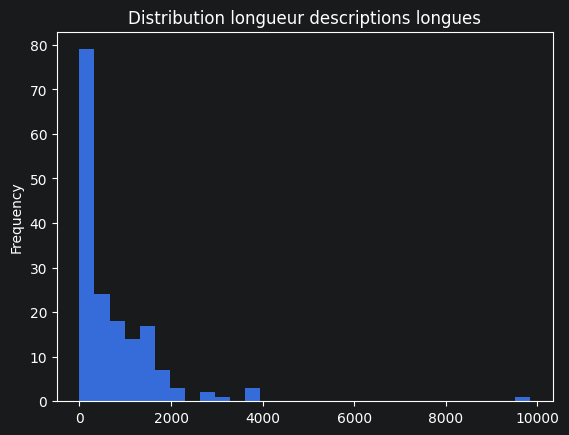

In [50]:
print("📏 Longueur des descriptions (caractères) :\n")
print(df[["title_len", "description_len", "longDescription_len"]].describe().round(0))

print("\n📊 Histogramme longDescription_len :")
df["longDescription_len"].plot(kind="hist", bins=30, title="Distribution longueur descriptions longues");

**🎯 Décision chunking** :
- Si médiane < 1000 caractères → **pas de chunking nécessaire**, 1 événement = 1 document
- Si médiane > 2000 caractères → **chunking recommandé** (par exemple 500-1000 caractères avec overlap)

### 4.2 Fraîcheur — événements < 1 an

In [57]:
df["last_end_dt"] = pd.to_datetime(df["last_end"], errors="coerce", utc=True)
now = datetime.now(timezone.utc)
one_year_ago = now - timedelta(days=365)

df["is_recent"] = df["last_end_dt"] >= one_year_ago
df["is_future"] = df["last_end_dt"] >= now

print(f"🗓️ Aujourd'hui : {now.date()}")
print(f"🗓️ Il y a 1 an : {one_year_ago.date()}\n")
print(f"Total échantillon         : {len(df)}")
print(f"Événements < 1 an         : {df['is_recent'].sum()}")
print(f"Événements à venir        : {df['is_future'].sum()}")
print(f"Date min (last_end)       : {df['last_end_dt'].min()}")
print(f"Date max (last_end)       : {df['last_end_dt'].max()}")

🗓️ Aujourd'hui : 2026-06-02
🗓️ Il y a 1 an : 2025-06-02

Total échantillon         : 169
Événements < 1 an         : 169
Événements à venir        : 169
Date min (last_end)       : 2026-06-02 19:30:00+00:00
Date max (last_end)       : 2027-06-20 18:00:00+00:00


### 4.3 Couverture des champs

In [52]:
print("📋 Taux de complétude (% non-vides) :\n")
completeness = {
    "title": (df["title"].str.len() > 0).mean() * 100,
    "description": (df["description"].str.len() > 0).mean() * 100,
    "longDescription": (df["longDescription_len"] > 0).mean() * 100,
    "city": df["city"].notna().mean() * 100,
    "postal_code": df["postal_code"].notna().mean() * 100,
    "last_end": df["last_end"].notna().mean() * 100,
    "keywords": df["keywords"].apply(lambda x: bool(x)).mean() * 100,
}
for k, v in completeness.items():
    print(f"  {k:25s} : {v:5.1f}%")

📋 Taux de complétude (% non-vides) :

  title                     :  99.4%
  description               :  99.4%
  longDescription           :  90.5%
  city                      : 100.0%
  postal_code               : 100.0%
  last_end                  : 100.0%
  keywords                  :   6.5%


### 4.4 Présence de HTML ?

In [53]:
import re
html_pattern = re.compile(r"<[a-zA-Z][^>]*>")

def has_html(text: str) -> bool:
    return bool(html_pattern.search(text or ""))

# Récupérer le texte longDescription brut depuis events_sample
long_descs = [extract_text(e.get("longDescription")) for e in events_sample]
html_count = sum(1 for d in long_descs if has_html(d))
print(f"🔍 Descriptions contenant du HTML : {html_count}/{len(long_descs)} ({html_count/len(long_descs)*100:.1f}%)")

# Échantillon d'une description avec HTML s'il y en a
for d in long_descs:
    if has_html(d):
        print("\n📌 Exemple de HTML détecté :")
        print(d[:500])
        break

🔍 Descriptions contenant du HTML : 0/169 (0.0%)


## 5. Décision finale — paramètres du POC

Sur la base des observations ci-dessus, on verrouille les paramètres pour `src/config.py`.

À compléter une fois les cellules exécutées :

| Paramètre | Valeur retenue | Justification |
|-----------|----------------|---------------|
| `AGENDA_UID` | _(à remplir)_ | _(taille, fraîcheur, diversité)_ |
| `MAX_EVENT_AGE_DAYS` | 365 | Exigence brief Jérémy |
| `Chunking` | _(oui/non + paramètres)_ | _(selon distribution longueurs)_ |
| `Préprocessing HTML` | _(oui/non)_ | _(selon présence HTML)_ |
| `Champs embeddés` | _(title + description + ?)_ | _(richesse sémantique vs bruit)_ |

---

## 💾 Sauvegarde de l'échantillon brut

On garde l'échantillon pour reproductibilité.

In [54]:
output_path = Path("..") / "data" / "raw" / "sample_exploration.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(events_sample, f, ensure_ascii=False, indent=2)
print(f"✅ Échantillon sauvegardé : {output_path}")
print(f"   Taille : {output_path.stat().st_size / 1024:.1f} KB")

✅ Échantillon sauvegardé : ../data/raw/sample_exploration.json
   Taille : 1125.0 KB


In [55]:
from datetime import datetime, timezone

print("=" * 60)
print("🔍 DIAGNOSTIC API — Diocèse de Paris")
print("=" * 60)

# Test 1 : appel "brut" (comme dans ton notebook actuel)
r = requests.get(
    f"{BASE_URL}/agendas/{AGENDA_UID}/events",
    params={"key": API_KEY, "size": 100, "detailed": 1},
    timeout=15,
)
data = r.json()
print(f"\n📊 Test 1 — Appel brut")
print(f"   total déclaré par l'API : {data.get('total')}")
print(f"   events retournés         : {len(data.get('events', []))}")
print(f"   after (cursor suivant)   : {data.get('after')}")

# Test 2 : on demande explicitement les événements à VENIR
r = requests.get(
    f"{BASE_URL}/agendas/{AGENDA_UID}/events",
    params={
        "key": API_KEY,
        "size": 100,
        "detailed": 1,
        "timings[gte]": datetime.now(timezone.utc).isoformat(),
    },
    timeout=15,
)
data = r.json()
print(f"\n📊 Test 2 — Filtre 'événements à venir' explicite")
print(f"   total déclaré par l'API : {data.get('total')}")
print(f"   events retournés         : {len(data.get('events', []))}")

# Test 3 : tri par lastTiming descendant (les + récents d'abord)
r = requests.get(
    f"{BASE_URL}/agendas/{AGENDA_UID}/events",
    params={
        "key": API_KEY,
        "size": 100,
        "detailed": 1,
        "sort": "lastTimingWithDeferred.desc",
    },
    timeout=15,
)
data = r.json()
print(f"\n📊 Test 3 — Tri par dernière date descendant")
print(f"   total déclaré par l'API : {data.get('total')}")
print(f"   events retournés         : {len(data.get('events', []))}")

# Test 4 : on inspecte les dates des events retournés en Test 1
print(f"\n📅 Dates des events du Test 1 (montrant le tri par défaut) :")
r = requests.get(
    f"{BASE_URL}/agendas/{AGENDA_UID}/events",
    params={"key": API_KEY, "size": 5, "detailed": 1},
    timeout=15,
)
for ev in r.json().get("events", [])[:5]:
    title = ev.get("title", {}).get("fr", "?")[:50]
    first = ev.get("firstTiming", {}).get("begin", "?")
    last = ev.get("lastTiming", {}).get("end", "?")
    print(f"   • {title:50s} | first={first[:10]} | last={last[:10]}")

🔍 DIAGNOSTIC API — Diocèse de Paris

📊 Test 1 — Appel brut
   total déclaré par l'API : 9798
   events retournés         : 100
   after (cursor suivant)   : ['0', '000001781721000', '1781724600000', '99043474']

📊 Test 2 — Filtre 'événements à venir' explicite
   total déclaré par l'API : 169
   events retournés         : 100

📊 Test 3 — Tri par dernière date descendant
   total déclaré par l'API : 9798
   events retournés         : 100

📅 Dates des events du Test 1 (montrant le tri par défaut) :
   • Prière du Chapelet                                 | first=2026-05-04 | last=2026-07-04
   • Comment agir en chrétien dans le monde contemporai | first=2026-03-31 | last=2026-06-16
   • Les mardis du dimanche                             | first=2026-05-05 | last=2026-06-30
   • Dîner du silence : À l'école de sainte Hildegarde  | first=2026-06-02 | last=2026-06-02
   • Et si je décidais de mieux m'aimer ?               | first=2026-05-19 | last=2026-06-02


In [56]:
import urllib.parse

# Appel 1 : on récupère le cursor "after"
r = requests.get(
    f"{BASE_URL}/agendas/{AGENDA_UID}/events",
    params={
        "key": API_KEY,
        "size": 5,
        "detailed": 0,
        "timings[gte]": datetime.now(timezone.utc).isoformat(),
    },
    timeout=15,
)
data = r.json()
after_cursor = data.get("after")
print(f"📦 Type du cursor 'after' : {type(after_cursor).__name__}")
print(f"📦 Valeur brute            : {after_cursor}")
print(f"📦 Total déclaré           : {data.get('total')}")
print(f"📦 Events retournés        : {len(data.get('events', []))}")

# Maintenant on essaie 4 formats pour passer ce cursor à l'appel suivant
test_formats = {
    "A - liste passée telle quelle (requests fait du repeat-key)":
        {"after": after_cursor},
    "B - JSON-string":
        {"after": json.dumps(after_cursor)},
    "C - join virgule":
        {"after": ",".join(after_cursor)} if isinstance(after_cursor, list) else None,
    "D - 4 params séparés after[0]..after[3]":
        {f"after[{i}]": v for i, v in enumerate(after_cursor)} if isinstance(after_cursor, list) else None,
}

print("\n" + "=" * 60)
print("🧪 Test des 4 formats de cursor")
print("=" * 60)

for name, params_extra in test_formats.items():
    if params_extra is None:
        continue
    params = {
        "key": API_KEY,
        "size": 5,
        "detailed": 0,
        "timings[gte]": datetime.now(timezone.utc).isoformat(),
        **params_extra,
    }
    r = requests.get(
        f"{BASE_URL}/agendas/{AGENDA_UID}/events",
        params=params,
        timeout=15,
    )
    status = "✅" if r.ok else "❌"
    n_events = len(r.json().get("events", [])) if r.ok else 0
    print(f"{status} Format {name}")
    print(f"   Status: {r.status_code} | Events retournés: {n_events}")
    if not r.ok:
        # Affiche le début du message d'erreur
        print(f"   Erreur: {r.text[:200]}")
    print()

📦 Type du cursor 'after' : list
📦 Valeur brute            : ['0', '000001780423200', '1780430400000', '58524348']
📦 Total déclaré           : 169
📦 Events retournés        : 5

🧪 Test des 4 formats de cursor
✅ Format A - liste passée telle quelle (requests fait du repeat-key)
   Status: 200 | Events retournés: 5

❌ Format B - JSON-string
   Status: 400 | Events retournés: 0
   Erreur: {"message":"invalid after value","info":{}}

❌ Format C - join virgule
   Status: 400 | Events retournés: 0
   Erreur: {"message":"invalid after value","info":{}}

✅ Format D - 4 params séparés after[0]..after[3]
   Status: 200 | Events retournés: 5



## 5. Décision finale — paramètres du POC

### 5.1 Choix de l'agenda source

**Agenda retenu** : Diocèse de Paris (`uid=82290100`, `slug=dioceseparis`)

**Justification** :
- **Volume adéquat** : 169 événements à venir, dans le sweet spot d'un POC (assez pour démontrer le retrieval, assez restreint pour des coûts d'embedding maîtrisés)
- **Diversité événementielle** : conférences, ateliers, célébrations, formations, dîners thématiques — couvre plusieurs cas d'usage
- **Qualité des données** : 100% de complétude sur les champs critiques (title, longDescription, location, dates), pas de HTML à nettoyer
- **Architecture agnostique** : la pipeline accepte n'importe quel `AGENDA_UID` — étendre à d'autres sources est une question de configuration, pas de code

**Note pour la V2** : en production, Puls-Events agrégerait plusieurs agendas en parallèle pour offrir une couverture exhaustive (Ville de Paris, IDF, festivals nationaux, etc.). Le POC valide ici la faisabilité technique sur un périmètre maîtrisé.

In [58]:
# Investigation : events avec champs vides
print("🔍 Events problématiques :\n")
print(f"Events sans title       : {(df['title_len'] == 0).sum()}")
print(f"Events sans description : {(df['description_len'] == 0).sum()}")
print(f"Events sans longDesc    : {(df['longDescription_len'] == 0).sum()}")
print(f"Events tout vide        : {((df['title_len']==0) & (df['longDescription_len']==0)).sum()}\n")

# Affiche les events problématiques
problematic = df[df['title_len'] == 0]
print(f"📋 Détail des events sans titre ({len(problematic)}) :")
print(problematic[['title', 'description', 'longDescription_len', 'city']].head(10))

# Affiche aussi le top des plus longs
print(f"\n📋 Top 5 des descriptions les plus longues :")
print(df.nlargest(5, 'longDescription_len')[['title', 'longDescription_len']])

🔍 Events problématiques :

Events sans title       : 1
Events sans description : 1
Events sans longDesc    : 16
Events tout vide        : 1

📋 Détail des events sans titre (1) :
   title description  longDescription_len   city
75                                      0  Paris

📋 Top 5 des descriptions les plus longues :
                                                title  longDescription_len
24  Médecine, IA et écologie : sobriété ou démesure ?                 9850
82                             Dimanches de Jérusalem                 3901
28        Journée des bénévoles - samedi 6 juin  2026                 3809
91  Comment faire œuvre de vérité et justice pour ...                 3778
59  La dette sociale : l'État peut-il porter seul ...                 3181
